<a href="https://colab.research.google.com/github/ErenB02/compneuro/blob/main/project/MNE_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
# @title Data retrieval
import os, requests

fname = 'fingerflex.npz'
url = "https://osf.io/5m47z/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

In [2]:
# @title Data loading
import numpy as np

alldat = np.load(fname, allow_pickle=True)['dat']

# Select just one of the recordings here. This is subject 1, block 1.
dat = alldat[0][0]

print(dat.keys())

dict_keys(['V', 'dg', 't_on', 't_off', 'stim_id', 'stimtext', 'srate', 'locs', 'hemisphere', 'lobe', 'gyrus', 'Brodmann_Area'])


In [43]:
dat['stimtext']

[np.str_('thumb'),
 np.str_('fore'),
 np.str_('middle'),
 np.str_('fourth'),
 np.str_('pinky')]

In [6]:
dat['V'].shape

(610040, 84)

In [7]:
# !pip install -q mne pyvista trame trame-vtk trame-vuetify ipympl

from IPython import get_ipython
get_ipython().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

In [46]:
from google.colab import output
output.enable_custom_widget_manager()

import mne
import pyvista as pv

pv.set_jupyter_backend("trame")
mne.viz.set_browser_backend("matplotlib")

srate = 1000.0
n_channels = dat['V'].shape[1]
ch_names = [f'ECoG_{i:03d}' for i in range(n_channels)]

info = mne.create_info(ch_names=ch_names, sfreq=srate, ch_types='ecog')
raw = mne.io.RawArray(dat['V'].T.astype('float64'), info)

# Attach 3D locations for spatial analysis
if 'locs' in dat:
    montage = mne.channels.make_dig_montage(ch_pos=dict(zip(ch_names, dat['locs'])), coord_frame='head')
    raw.set_montage(montage)

# Attach events (finger flexions) as Annotations
onsets = dat['t_on'].flatten() / srate
durations = (dat['t_off'].flatten() - dat['t_on'].flatten()) / srate
descriptions = [f"Finger_{int(c)}" for c in dat['stim_id'].flatten()]
raw.set_annotations(mne.Annotations(onset=onsets, duration=durations, description=descriptions))

print("MNE Raw object ready.")

Creating RawArray with float64 data, n_channels=84, n_times=610040
    Range : 0 ... 610039 =      0.000 ...   610.039 secs
Ready.
MNE Raw object ready.


In [8]:
raw.notch_filter([60], trans_bandwidth=3)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 58 - 62 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 58.35
- Lower transition bandwidth: 1.50 Hz (-6 dB cutoff frequency: 57.60 Hz)
- Upper passband edge: 61.65 Hz
- Upper transition bandwidth: 1.50 Hz (-6 dB cutoff frequency: 62.40 Hz)
- Filter length: 2201 samples (2.201 s)



<RawArray | 84 x 610040 (610.0 s), ~391.1 MiB, data loaded>

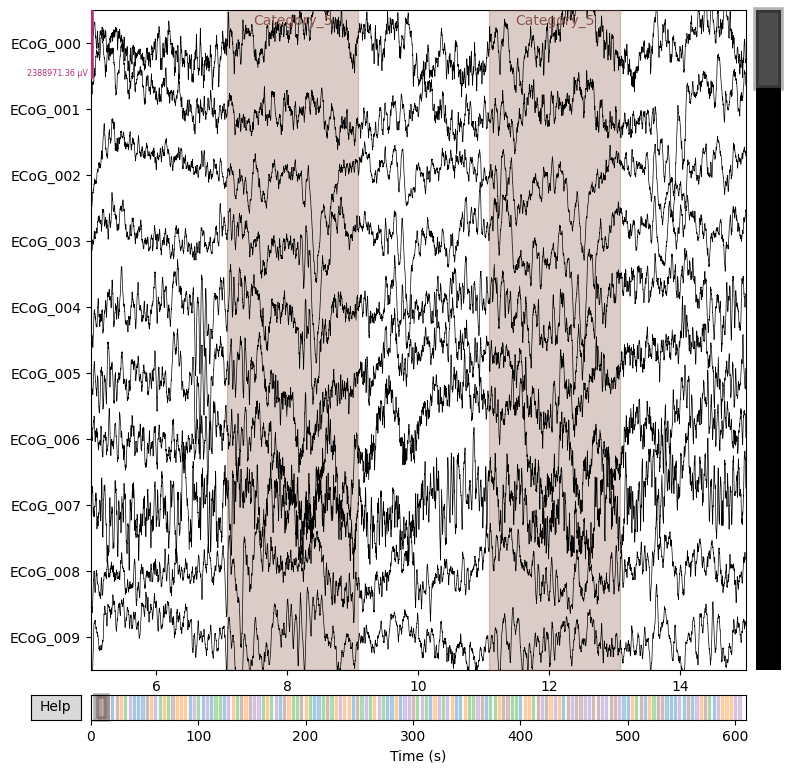

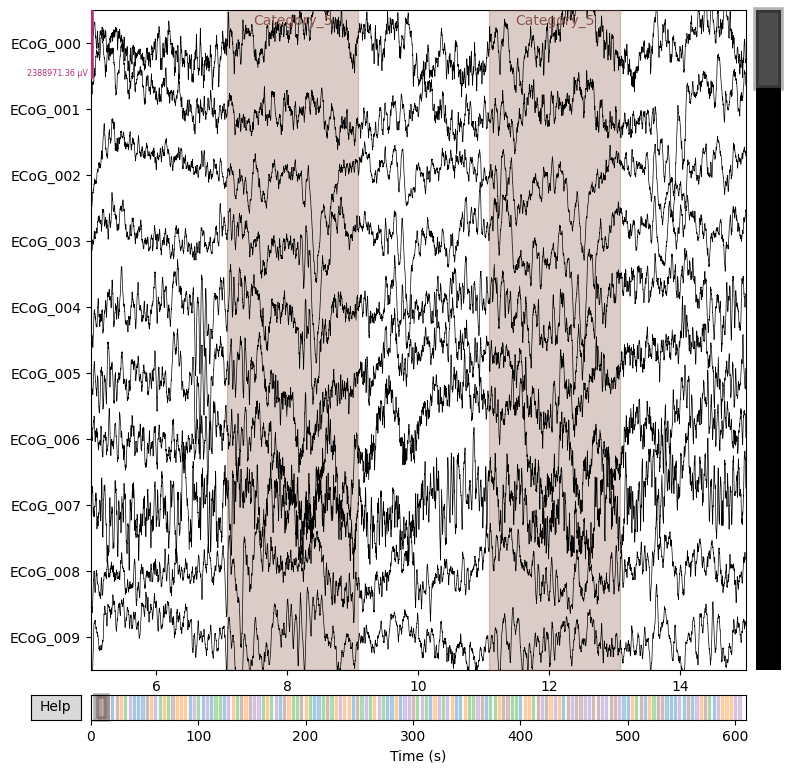

In [16]:
raw.plot(start=5.0, duration=10.0, n_channels=10, decim='auto', scalings='auto', block=False)

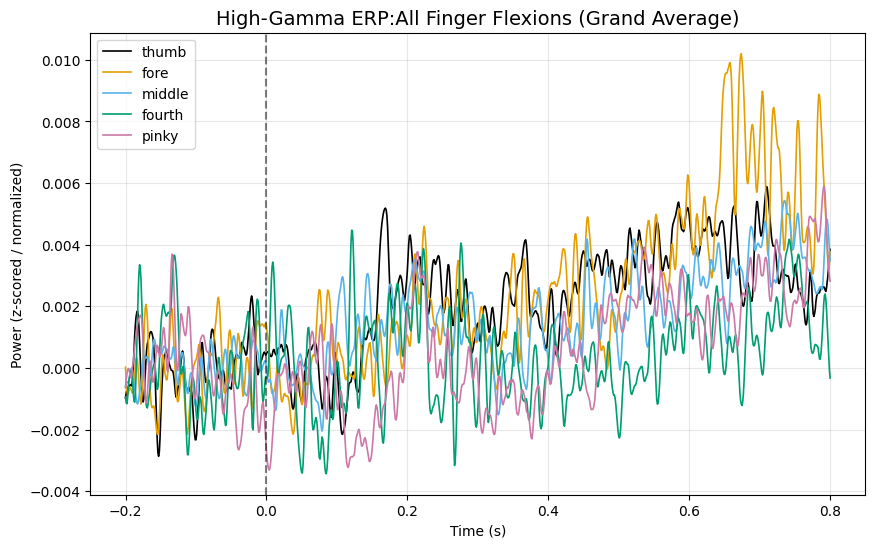

In [62]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# 1. Filter and extract High-Gamma envelope (50-200 Hz)
raw_gamma = raw.copy().filter(l_freq=70., h_freq=150., fir_design='firwin', verbose=False)
raw_gamma.apply_hilbert(envelope=True)

# 2. Extract epochs based on all fingers
events, event_id = mne.events_from_annotations(raw_gamma, verbose=False)
epochs_gamma = mne.Epochs(raw_gamma, events, event_id, tmin=-0.2, tmax=0.8, baseline=(-0.2, 0), preload=True, verbose=False)

# 3. Create Evoked responses for each category
# event_id is usually {'Category_1': 1, 'Category_2': 2}
finger_1 = epochs_gamma['Finger_1'].average()
finger_2 = epochs_gamma['Finger_2'].average()
finger_3 = epochs_gamma['Finger_3'].average()
finger_4 = epochs_gamma['Finger_4'].average()
finger_5 = epochs_gamma['Finger_5'].average()


# 4. Plot overlapping ERPs
# We'll use the average across all channels or a specific responsive channel
fig, ax = plt.subplots(figsize=(10, 6))

# Average across all ECoG channels
times = finger_1.times
finger1 = finger_1.data.mean(axis=0)
finger2 = finger_2.data.mean(axis=0)
finger3 = finger_3.data.mean(axis=0)
finger4 = finger_4.data.mean(axis=0)
finger5 = finger_5.data.mean(axis=0)


ax.plot(times, finger1, label='thumb', color='#000000', linewidth=1.2)
ax.plot(times, finger2, label='fore', color='#E69F00', linewidth=1.2)
ax.plot(times, finger3, label='middle', color='#56B4E9', linewidth=1.2)
ax.plot(times, finger4, label='fourth', color='#009E73', linewidth=1.2)
ax.plot(times, finger5, label='pinky', color='#CC79A7', linewidth=1.2)

ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title("High-Gamma ERP:All Finger Flexions (Grand Average)", fontsize=14)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (z-scored / normalized)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

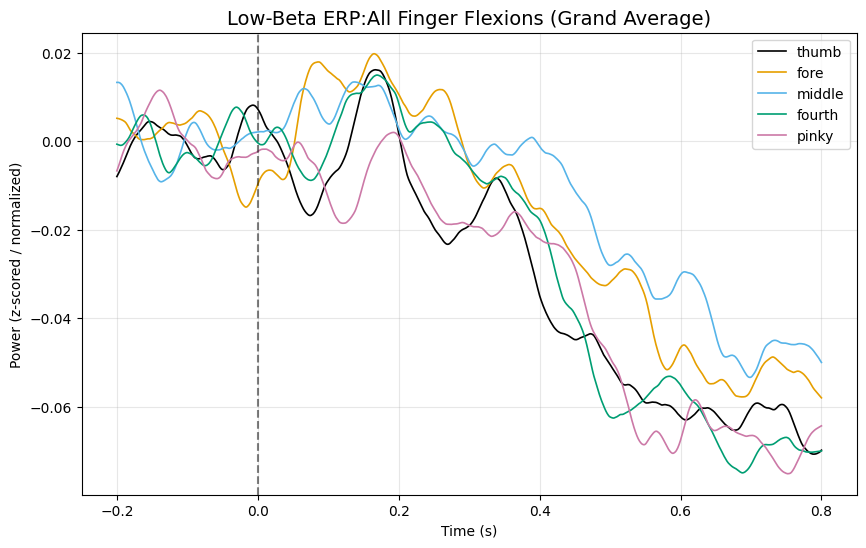

In [63]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# 1. Filter and extract Low-Beta envelope (50-200 Hz)
raw_beta = raw.copy().filter(l_freq=12., h_freq=30., fir_design='firwin', verbose=False)
raw_beta.apply_hilbert(envelope=True)

# 2. Extract epochs based on all fingers
events, event_id = mne.events_from_annotations(raw_beta, verbose=False)
epochs_beta = mne.Epochs(raw_beta, events, event_id, tmin=-0.2, tmax=0.8, baseline=(-0.2, 0), preload=True, verbose=False)

# 3. Create Evoked responses for each category
# event_id is usually {'Category_1': 1, 'Category_2': 2}
finger_1 = epochs_beta['Finger_1'].average()
finger_2 = epochs_beta['Finger_2'].average()
finger_3 = epochs_beta['Finger_3'].average()
finger_4 = epochs_beta['Finger_4'].average()
finger_5 = epochs_beta['Finger_5'].average()


# 4. Plot overlapping ERPs
# We'll use the average across all channels or a specific responsive channel
fig, ax = plt.subplots(figsize=(10, 6))

# Average across all ECoG channels
times = finger_1.times
finger1 = finger_1.data.mean(axis=0)
finger2 = finger_2.data.mean(axis=0)
finger3 = finger_3.data.mean(axis=0)
finger4 = finger_4.data.mean(axis=0)
finger5 = finger_5.data.mean(axis=0)


ax.plot(times, finger1, label='thumb', color='#000000', linewidth=1.2)
ax.plot(times, finger2, label='fore', color='#E69F00', linewidth=1.2)
ax.plot(times, finger3, label='middle', color='#56B4E9', linewidth=1.2)
ax.plot(times, finger4, label='fourth', color='#009E73', linewidth=1.2)
ax.plot(times, finger5, label='pinky', color='#CC79A7', linewidth=1.2)

ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title("Low-Beta ERP:All Finger Flexions (Grand Average)", fontsize=14)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (z-scored / normalized)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()